<a href="https://colab.research.google.com/github/ji0-k/AI_26/blob/main/07_02_%EC%8B%AC%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D(%EB%94%A5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 인공 신경망에 층을 추가하여 데이터셋을 분류하면 딥! -> 심층 신경망

import tensorflow as tf
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고
# 텐서플로 연산을 결정적으로 만듭니다.

from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
# 딥러닝의 데이터 불러오기, 파이썬 특유의 언패킹(Unpacking)이라는 기술
# (train_input, train_target):모델이 학습할 때 쓸 훈련 데이터
# (test_input, test_target) : 모델의 최종 실력 검증할 테스트 데이터

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 심층신경망 만들기 전 , 데이터 정규화 필요
from sklearn.model_selection import train_test_split

# 0~255사이의 값을 0~1 사이로 정규화 : 왜냐면 너무 숫자가 커져버려
train_scaled = train_input / 255.0

# 2차원(28, 28)을 1차원(784)으로 펼치기
# 왜냐면 Dense 레이어(밀집층)는 데이터를 받을 때 한 줄로 받음
train_scaled = train_scaled.reshape(-1, 28*28)
# 파라미터 -1, 행(사진장수)원래대로 유지하고 열(픽셀)만 784로 맞춰라

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [ ]:
print(test_input.shape, test_target.shape) #최종검증데이터, 답
print(train_scaled.shape, train_target.shape) #학습데이터, 답
print(val_scaled.shape, val_target.shape) #중간검증테이터 , 답

(10000, 28, 28) (10000,)
(48000, 784) (48000,)
(12000, 784) (12000,)


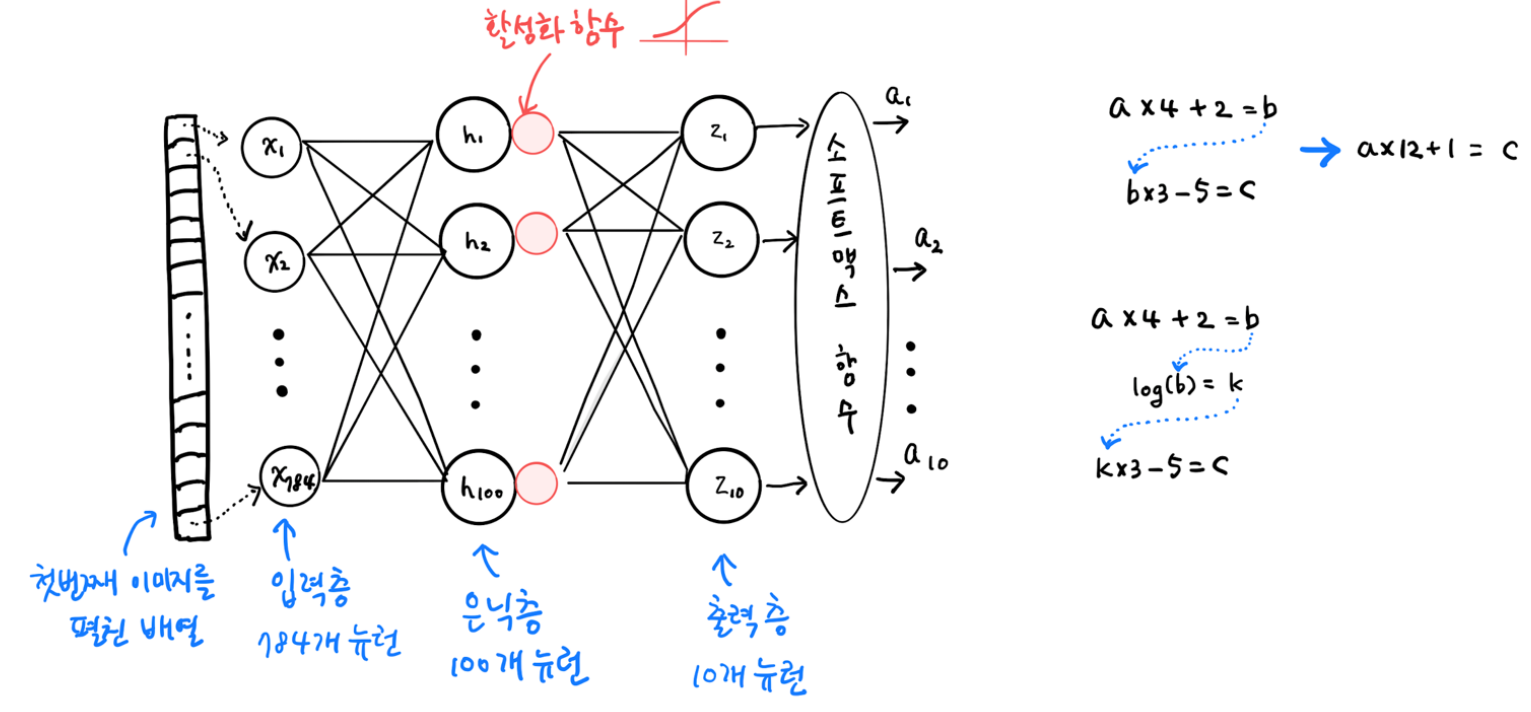

In [ ]:
# 은닉층(hidden layer) 입력층 출력층 사이에 위치, 데이터의 복잡한 특징 추출
# 비선형 활성화 함수(Crucial!) 신경망이 단순한 선형 계산($y = ax + b$)만 반복하면 층을 아무리 쌓아도 결국 하나의 큰 선형 계산과 같습니다
#                              이를 막기 위해 비선형성을 주입하여 데이터의 복잡한 패턴(곡선 등)을 학습할 수 있게 합니다
# 활성화 함수 종류
# 시그모이드(Sigmoid): 전통적인 함수. 출력을 0~1 사이로 압축하지만, 층이 깊어지면 학습이 안 되는 단점
# ReLU (추천): $0$보다 작으면 $0$, 크면 자기 자신을 출력. 연산이 빠르고 현대 딥러닝의 표준
# 소프트맥스(Softmax): 출력층 전용. 모든 출력값의 합을 1(100%)로 만들어 확률로 해석하게 해줍니다.

In [ ]:
# 시그모이드 활성화 함수를 사용한 은닉층과 소프트맥스 함수를
# 사용한 출력층을 케라스 Dense 클래스로 만들어 보자.
from tensorflow import keras

# 1. 은닉층 정의 (100개의 뉴런)
# 실무 팁: 요즘은 'sigmoid' 대신 'relu'를 쓰는 것이 성능이 더 잘 나옵니다.
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,))
# input_shape=(784,) -> 입력 데이터의 피처(특성) 개수를 명시합니다.

# 2. 출력층 정의 (10개의 클래스 분류)
# 다중 분류이므로 10개의 뉴런과 'softmax' 함수를 사용합니다.
dense2 = keras.layers.Dense(10, activation='softmax')

# 3. 심층 신경망 모델 구성
# Sequential 클래스에 리스트 형태로 층을 차례로 담습니다.
model = keras.Sequential([dense1, dense2])

# 4. 모델 구조 확인 (매우 중요!)
# 모델이 몇 개의 파라미터(가중치+절편)를 학습하는지 한눈에 보여줍니다.
model.summary()

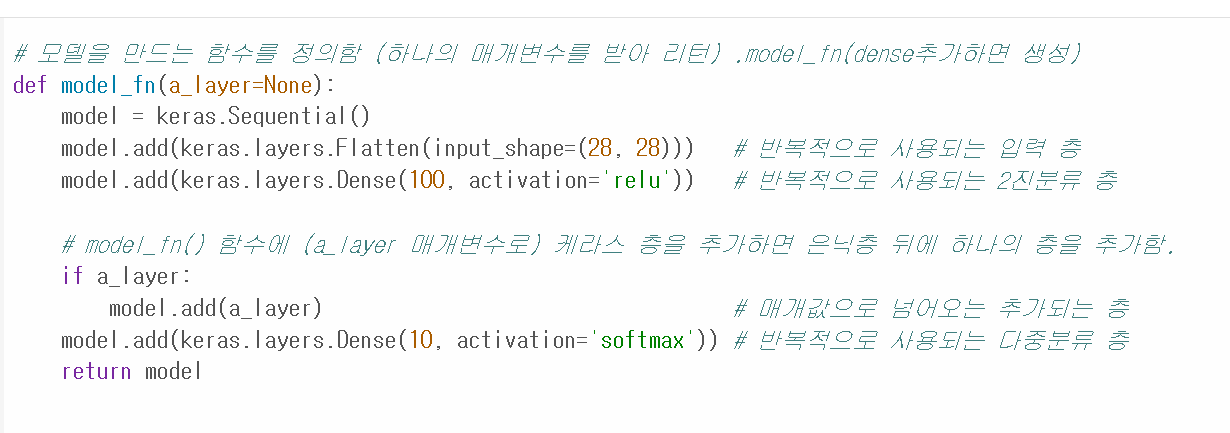